# EDA — RetailBoost: ¿el cliente va a comprar?

**Contexto de negocio:** RetailBoost es una empresa de retail que quiere anticipar si un cliente va a comprar (`compró` = 1) o no (`compró` = 0), usando datos simples: edad, ingresos mensuales, región y frecuencia de visitas.

**Importante:** en este notebook **no entrenamos ningún modelo todavía**. El objetivo es hacer un **Análisis Exploratorio de Datos (EDA)** para entender los datos, limpiarlos y dejarlos listos (features seleccionadas y transformadas) para un futuro modelo de clasificación.

Vamos a seguir estos pasos:
1. Cargar y explorar el dataset
2. Ver distribuciones de variables numéricas y categóricas
3. Limpiar datos nulos
4. Analizar correlaciones entre variables numéricas
5. Transformar features (escalado + encoding)
6. Seleccionar features preliminares para el modelo

## 1. Carga y exploración inicial

**Por qué:** usamos `pandas`/`numpy` para manipular datos, `matplotlib`/`seaborn` para graficar y `sklearn` para el escalado/encoding de más adelante. Cargamos el CSV con ruta relativa a `data/`, y miramos `.head()` (primeras filas, ¿son las columnas esperadas?) e `.info()` (tipos de dato y cuántos valores no nulos tiene cada columna — primera pista de dónde hay faltantes).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/retailboost_customers.csv")
print(df.shape)
df.head()

(500, 6)


,customer_id,edad,ingresos_mensuales,region,frecuencia_visitas,compró
0,1,56,3697.72,Norte,2,1
1,2,69,2825.97,Este,15,0
2,3,46,784.50,Este,14,0
3,4,32,1612.61,Oeste,11,0
4,5,60,3013.53,Este,3,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    int64  
 1   edad                500 non-null    int64  
 2   ingresos_mensuales  485 non-null    float64
 3   region              485 non-null    str    
 4   frecuencia_visitas  500 non-null    int64  
 5   compró              500 non-null    int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 23.6 KB


## 2. Distribuciones de las variables

**Por qué:** antes de limpiar o transformar nada, conviene entender cómo se distribuye cada variable: rangos, valores típicos, outliers evidentes y qué tan balanceadas están las categorías. Esto guía las decisiones de los pasos siguientes.

**Qué mirar:** `describe()` resume las numéricas (media, desvío, min/max, cuartiles); `value_counts()` muestra cuántos clientes hay por `region` y por clase del target `compró`.

In [3]:
display(df.describe())
print(df["region"].value_counts(dropna=False))
print()
print(df["compró"].value_counts(normalize=True))

,customer_id,edad,ingresos_mensuales,frecuencia_visitas,compró
count,500.000000,500.000000,485.000000,500.000000,500.000000
mean,250.500000,44.220000,1972.529052,9.928000,0.388000
std,144.481833,15.036082,797.388756,5.430082,0.487783
min,1.000000,18.000000,-593.010000,1.000000,0.000000
25%,125.750000,32.000000,1425.240000,5.000000,0.000000
50%,250.500000,45.000000,1973.840000,10.000000,0.000000
75%,375.250000,57.000000,2502.680000,15.000000,1.000000
max,500.000000,69.000000,4463.100000,19.000000,1.000000


region
Norte    134
Este     127
Sur      117
Oeste    107
NaN       15
Name: count, dtype: int64

compró
0    0.612
1    0.388
Name: proportion, dtype: float64


**Por qué graficar:** un histograma muestra de un vistazo la forma de la distribución (simétrica, sesgada, con outliers) mejor que solo mirar números. Graficamos las tres variables numéricas predictoras.

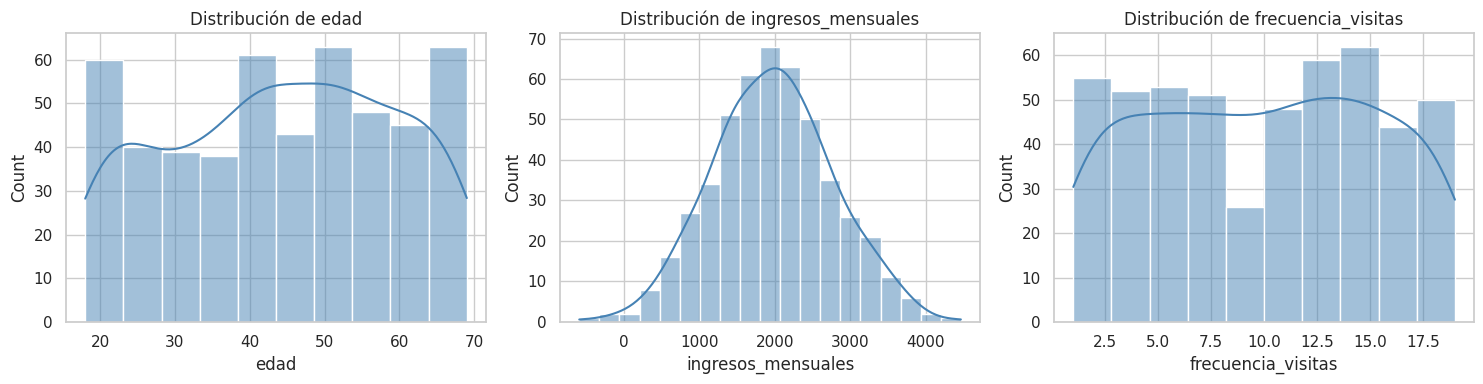

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["edad", "ingresos_mensuales", "frecuencia_visitas"]):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

## 3. Limpieza de datos nulos

**Por qué:** en `df.info()` vimos que `ingresos_mensuales` y `region` tienen faltantes. Primero cuantificamos cuántos y qué porcentaje representan.

**Decisión:** en ambos casos el porcentaje de nulos es bajo (~3%), así que en vez de descartar filas (y perder datos válidos de otras columnas) **imputamos**: `ingresos_mensuales` (numérica) con la **mediana** (robusta a outliers), y `region` (categórica) con la **moda** (la región más frecuente).

In [5]:
nulos = df.isna().sum()
pct = (nulos / len(df) * 100).round(2)
display(pd.DataFrame({"nulos": nulos, "%": pct}))

df["ingresos_mensuales"] = df["ingresos_mensuales"].fillna(df["ingresos_mensuales"].median())
df["region"] = df["region"].fillna(df["region"].mode()[0])

df.isna().sum()

,nulos,%
customer_id,0,0.0
edad,0,0.0
ingresos_mensuales,15,3.0
region,15,3.0
frecuencia_visitas,0,0.0
compró,0,0.0


customer_id           0
edad                  0
ingresos_mensuales    0
region                0
frecuencia_visitas    0
compró                0
dtype: int64

## 4. Matriz de correlación

**Por qué:** queremos ver qué tan relacionadas están entre sí las variables numéricas, por dos motivos: (a) detectar variables **redundantes** (muy correlacionadas entre sí, que aportarían información repetida a un futuro modelo) y (b) tener una primera idea de qué variables se relacionan más con el target `compró`.

**Qué mirar después del gráfico:** si `edad`, `ingresos_mensuales` y `frecuencia_visitas` tuvieran una correlación muy alta entre ellas (por ejemplo > 0.8), sería señal de redundancia y podría convenir descartar una. Si alguna tiene una correlación notable con `compró`, es una pista de que puede ser una feature útil.

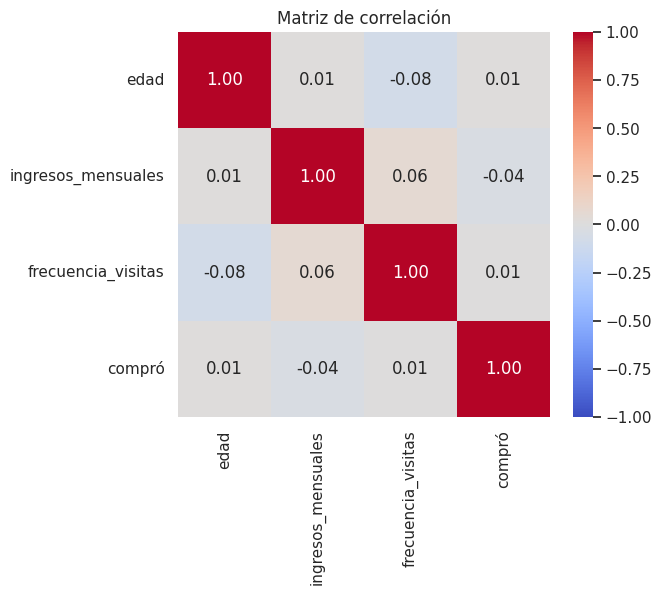

In [6]:
corr = df[["edad", "ingresos_mensuales", "frecuencia_visitas", "compró"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## 5. Transformación de features

**Por qué escalar:** `edad`, `ingresos_mensuales` y `frecuencia_visitas` están en escalas muy distintas (ingresos va de cientos a miles, edad de 18 a 69). Muchos modelos de ML (regresión logística, KNN, SVM) son sensibles a la escala, así que **estandarizamos** (media 0, desvío 1) las numéricas con `StandardScaler`.

**Por qué encoding:** `region` es texto y los modelos necesitan números. Como no tiene un orden natural, usamos **One-Hot Encoding**: crea una columna binaria por categoría, en vez de un número arbitrario que el modelo podría malinterpretar como una escala.

In [7]:
from sklearn.preprocessing import StandardScaler

num_cols = ["edad", "ingresos_mensuales", "frecuencia_visitas"]
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

df_encoded = pd.get_dummies(df_scaled, columns=["region"], prefix="region")
df_encoded.head()

,customer_id,edad,ingresos_mensuales,frecuencia_visitas,compró,region_Este,region_Norte,region_Oeste,region_Sur
0,1,0.784233,2.198971,-1.461477,1,False,True,False,False
1,2,1.649686,1.087791,0.934991,0,True,False,False,False
2,3,0.118500,-1.514376,0.750648,0,True,False,False,False
3,4,-0.813526,-0.458822,0.197616,0,False,False,True,False
4,5,1.050527,1.326866,-1.277133,0,True,False,False,False


## 6. Selección preliminar de features

**Por qué:** con los datos limpios, transformados y sin variables redundantes, ya podemos armar el conjunto de features (`X`) que usaría un futuro modelo, y separar el target (`y`). Descartamos `customer_id` porque es solo un identificador, no aporta información predictiva.

In [8]:
feature_cols = [c for c in df_encoded.columns if c not in ["customer_id", "compró"]]

X = df_encoded[feature_cols]
y = df_encoded["compró"]

print("Features seleccionadas:", list(X.columns))
print("Shape de X:", X.shape, "- Shape de y:", y.shape)

Features seleccionadas: ['edad', 'ingresos_mensuales', 'frecuencia_visitas', 'region_Este', 'region_Norte', 'region_Oeste', 'region_Sur']
Shape de X: (500, 7) - Shape de y: (500,)


## Conclusión

Este EDA nos permitió:
- Confirmar que el dataset tiene 500 clientes con pocas variables, aptas para un problema de clasificación binaria.
- Detectar y tratar nulos en `ingresos_mensuales` (mediana) y `region` (moda).
- Verificar que no hay redundancia fuerte entre las variables numéricas predictoras.
- Dejar las variables numéricas estandarizadas y `region` codificada con One-Hot, listas para un modelo.
- Armar un `X` (features) y un `y` (target `compró`) preliminares para la siguiente etapa: entrenar un modelo de clasificación.